In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df.head(3)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [7]:
df['Total_Earnings'] = df['Units Sold'] * df['Price'] * (1 - df['Discount']/100)
df['Products_to_sell'] = df['Units Ordered'] - df['Units Sold']

df['Price_diff'] = df['Price'] - df['Competitor Pricing']
df['Price_ratio'] = df['Price'] / (df['Competitor Pricing'] + 1e-6)
df['Price_gap_pct'] = (df['Price'] - df['Competitor Pricing']) / df['Competitor Pricing']
df['Discount_effect'] = df['Discount'] * df['Promotion']

df['Inventory_pressure'] = df['Inventory Level'] / (df['Inventory Level'] + 1)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [8]:
numeric_cols = df.select_dtypes(include="number").columns
object_cols = df.select_dtypes(include="object").columns

print("🔢 NUMERIC COLUMNS")
print("-" * 50)

for col in numeric_cols:
    nunique = df[col].nunique()
    print(f"\n📌 {col}")
    print(f"nunique: {nunique}")
    
    if nunique < 15:
        print("unique values:", df[col].unique())

print("\n" + "=" * 60)

print("🔤 OBJECT COLUMNS")
print("-" * 50)

for col in object_cols:
    nunique = df[col].nunique()
    print(f"\n📌 {col}")
    print(f"nunique: {nunique}")
    
    if nunique < 15:
        print("unique values:", df[col].unique())

🔢 NUMERIC COLUMNS
--------------------------------------------------

📌 Inventory Level
nunique: 1426

📌 Units Sold
nunique: 330

📌 Units Ordered
nunique: 996

📌 Price
nunique: 15396

📌 Discount
nunique: 6
unique values: [ 5 10  0 20 25 15]

📌 Promotion
nunique: 2
unique values: [0 1]

📌 Competitor Pricing
nunique: 15963

📌 Epidemic
nunique: 2
unique values: [0 1]

📌 Demand
nunique: 340

📌 Total_Earnings
nunique: 73251

📌 Products_to_sell
nunique: 1141

📌 Price_diff
nunique: 13230

📌 Price_ratio
nunique: 75841

📌 Price_gap_pct
nunique: 75447

📌 Discount_effect
nunique: 5
unique values: [ 0 20 10 25 15]

📌 Inventory_pressure
nunique: 1426

📌 Year
nunique: 3
unique values: [2022 2023 2024]

📌 Month
nunique: 12
unique values: [ 1  2  3  4  5  6  7  8  9 10 11 12]

📌 Day
nunique: 31

🔤 OBJECT COLUMNS
--------------------------------------------------

📌 Store ID
nunique: 5
unique values: ['S001' 'S004' 'S003' 'S005' 'S002']

📌 Product ID
nunique: 20

📌 Category
nunique: 5
unique values: ['

<div style="
background: linear-gradient(135deg, #020617 0%, #020617 100%);
border-radius: 14px;
padding: 18px 24px;
margin: 28px 0;
box-shadow: 0 12px 30px rgba(0,0,0,0.6);
font-family: Arial, Helvetica, sans-serif;
">

<h2 style="
margin: 0;
font-size: 26px;
font-weight: 700;
color: #e5e7eb;
letter-spacing: 0.6px;
">
📊 EDA & Visualization
</h2>

</div>

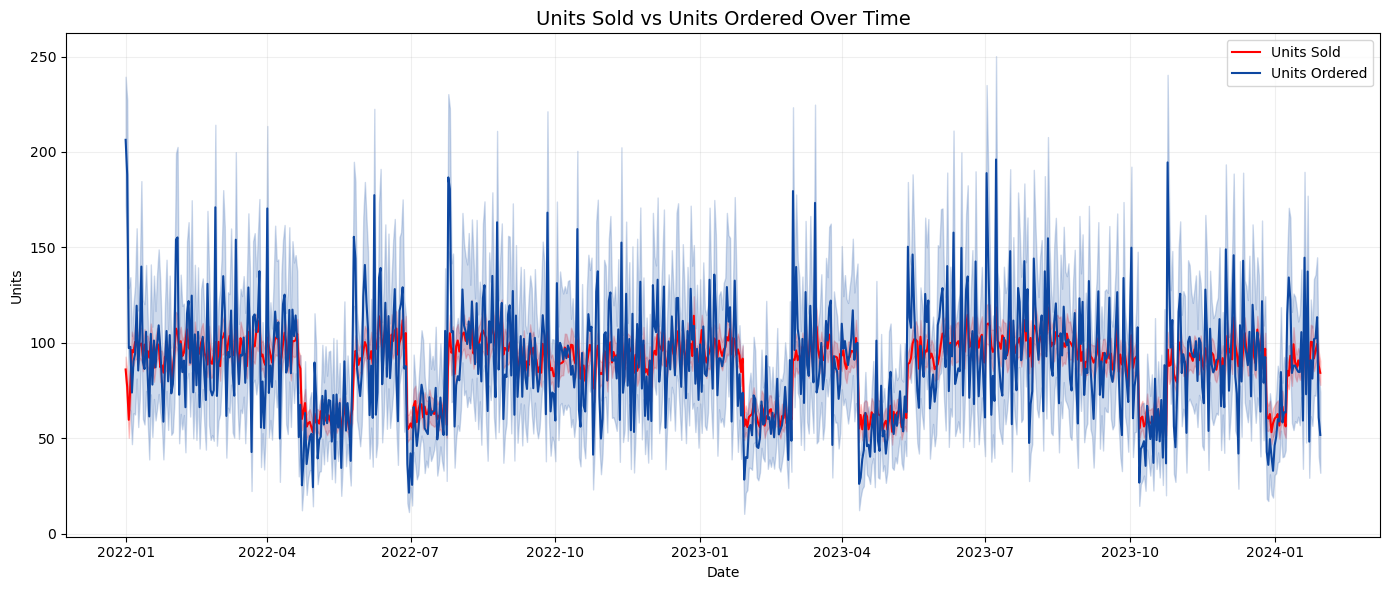

In [9]:
plt.figure(figsize=(14,6))

sns.lineplot(data=df, x='Date', y='Units Sold', label='Units Sold', color='red') 
sns.lineplot(data=df, x='Date', y='Units Ordered', label='Units Ordered', color='#0D47A1')  

plt.title("Units Sold vs Units Ordered Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Units")
plt.grid(alpha=0.2)

plt.legend()
plt.tight_layout()
plt.show()

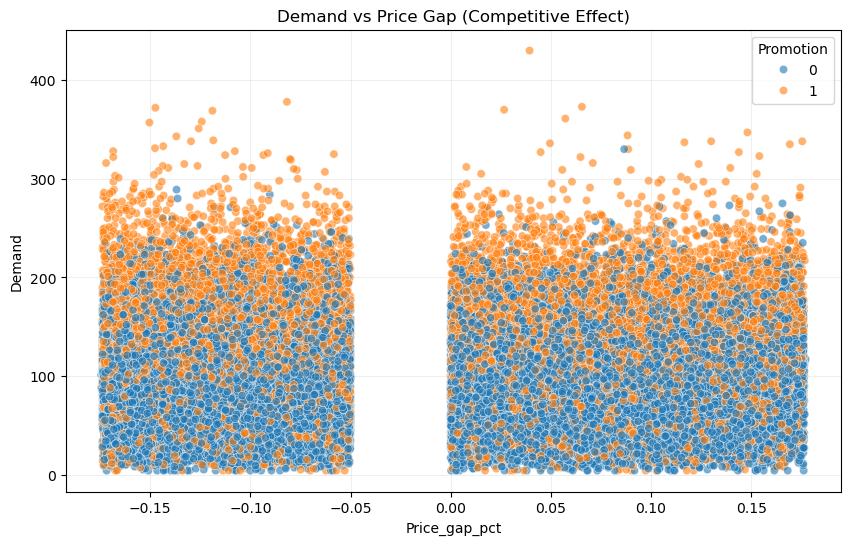

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Price_gap_pct',
    y='Demand',
    hue='Promotion',
    alpha=0.6
)

plt.title("Demand vs Price Gap (Competitive Effect)")
plt.grid(alpha=0.2)
plt.show()

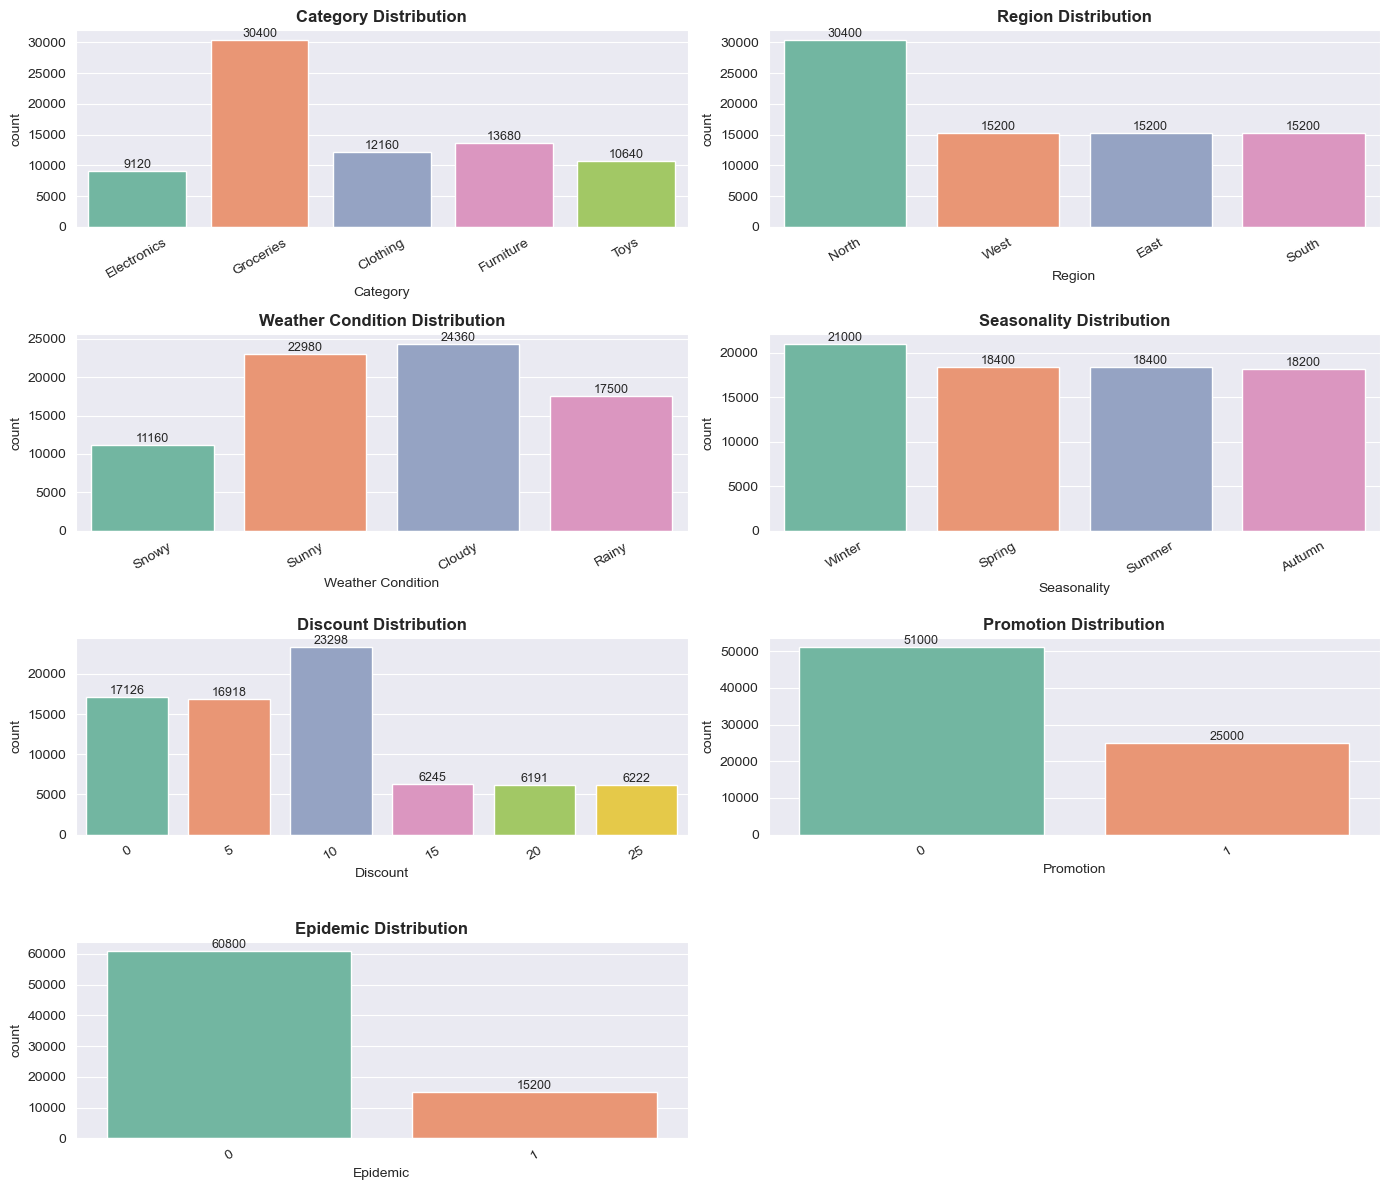

In [11]:
cols_for_count = ['Category','Region','Weather Condition','Seasonality','Discount','Promotion','Epidemic']
sns.set_style("darkgrid")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols_for_count):
    ax = sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=12, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)

if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

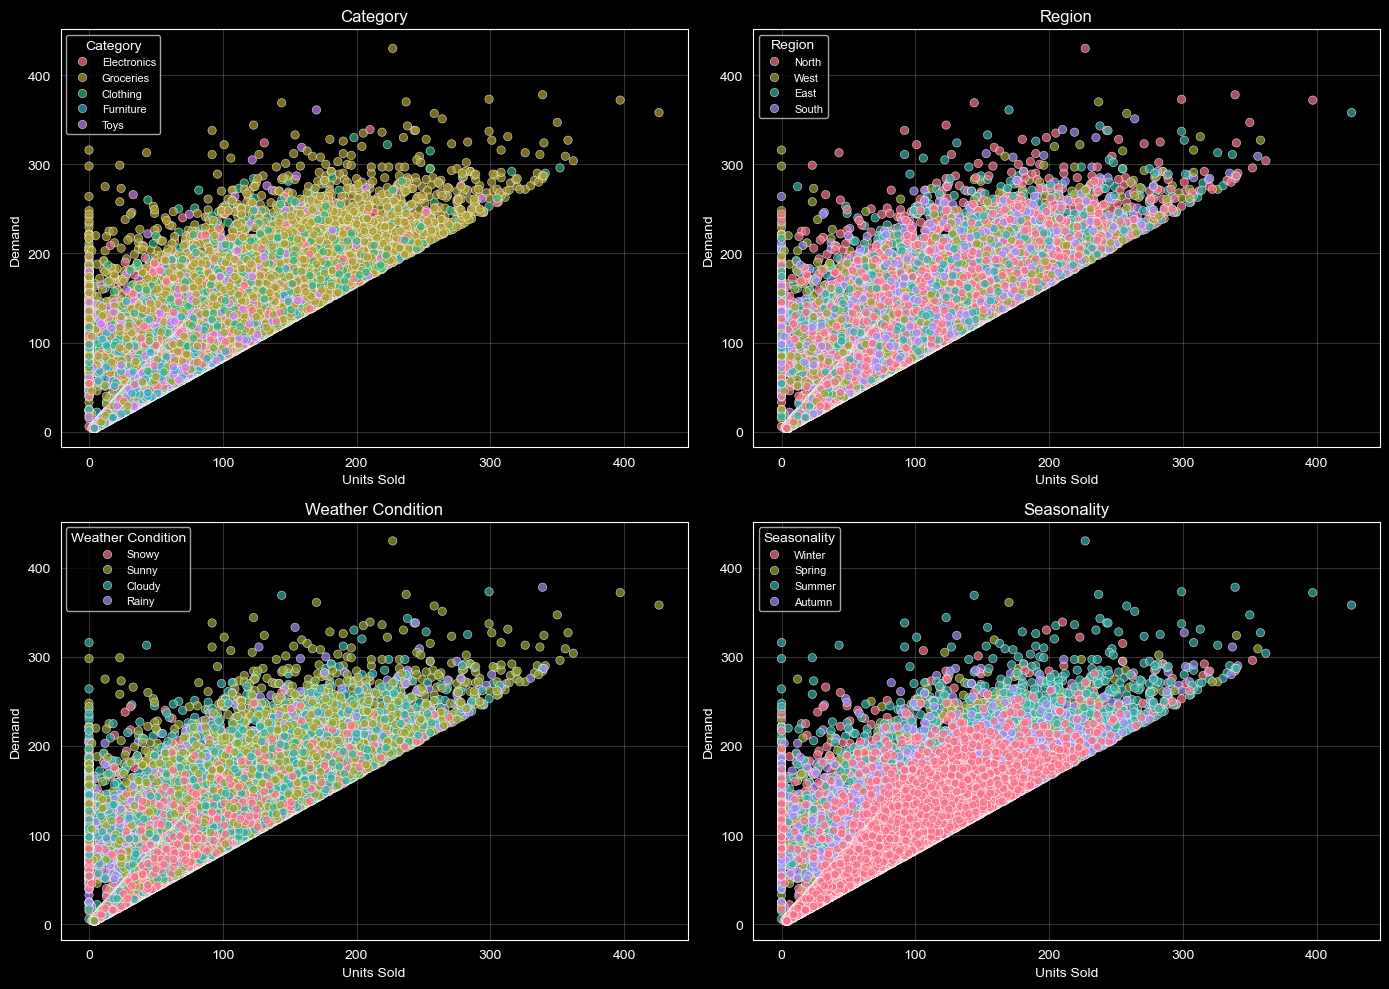

In [12]:
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']

plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()  

for i, col in enumerate(categorical_cols):
    
    n_colors = df[col].nunique()
    palette = sns.color_palette("husl", n_colors)
    
    sns.scatterplot(
        data=df,
        x='Units Sold',
        y='Demand',
        hue=col,
        palette=palette,
        alpha=0.7,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col}")
    axes[i].grid(alpha=0.2)
    
    axes[i].legend(title=col, fontsize=8)

plt.tight_layout()
plt.show()

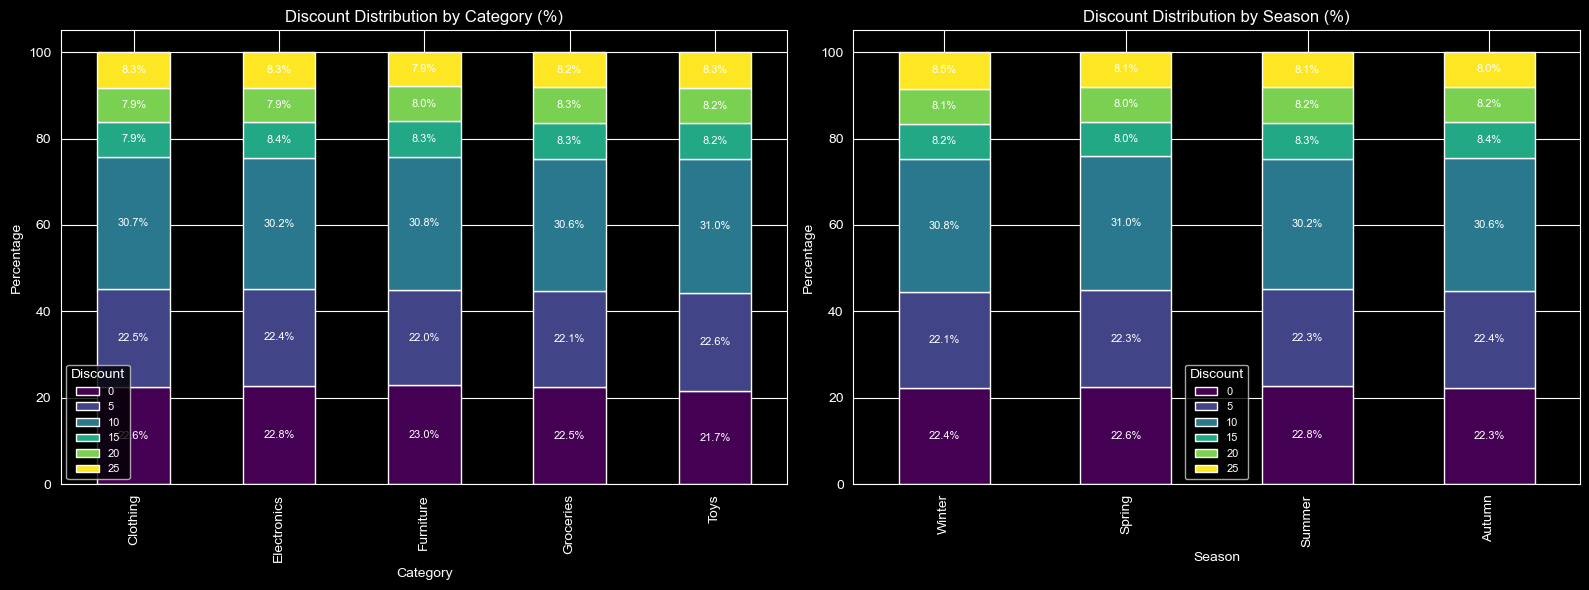

In [13]:
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(16,6))

ct_cat = pd.crosstab(df['Category'], df['Discount'])
ct_cat = ct_cat.sort_index(axis=1)
ct_cat_pct = ct_cat.div(ct_cat.sum(axis=1), axis=0) * 100

ax1 = ct_cat_pct.plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    ax=axes[0]
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

ax1.set_title("Discount Distribution by Category (%)")
ax1.set_xlabel("Category")
ax1.set_ylabel("Percentage")
ax1.legend(title="Discount", fontsize=8)


ct_season = pd.crosstab(df['Seasonality'], df['Discount'])
ct_season = ct_season.sort_index(axis=1)

order = ['Winter', 'Spring', 'Summer', 'Autumn']
ct_season = ct_season.loc[order]

ct_season_pct = ct_season.div(ct_season.sum(axis=1), axis=0) * 100

ax2 = ct_season_pct.plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    ax=axes[1]
)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

ax2.set_title("Discount Distribution by Season (%)")
ax2.set_xlabel("Season")
ax2.set_ylabel("Percentage")
ax2.legend(title="Discount", fontsize=8)


plt.tight_layout()
plt.show()

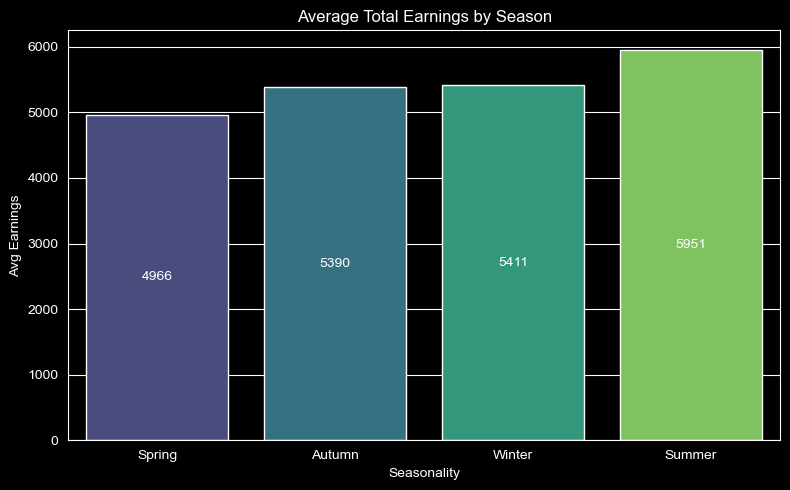

In [14]:
plt.figure(figsize=(8,5))

season_avg = df.groupby('Seasonality')['Total_Earnings'].mean().sort_values()

ax = sns.barplot(
    x=season_avg.index,
    y=season_avg.values,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='center')

plt.title("Average Total Earnings by Season")
plt.ylabel("Avg Earnings")

plt.tight_layout()
plt.show()

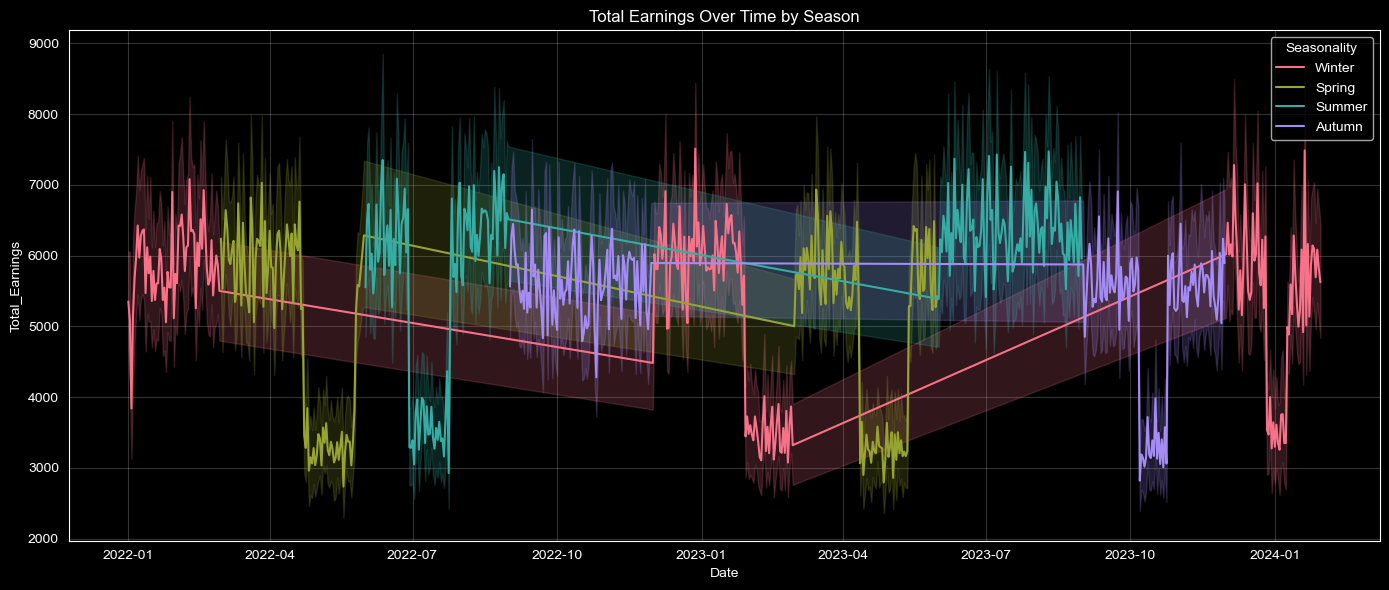

In [15]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Total_Earnings',
    hue='Seasonality',
    palette='husl'
)

plt.title("Total Earnings Over Time by Season")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

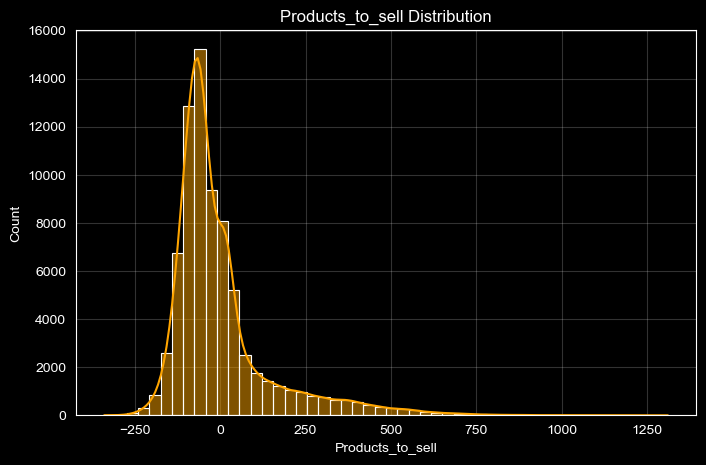

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Products_to_sell'], bins=50, kde=True, color='orange')

plt.title("Products_to_sell Distribution")
plt.grid(alpha=0.2)

plt.show()

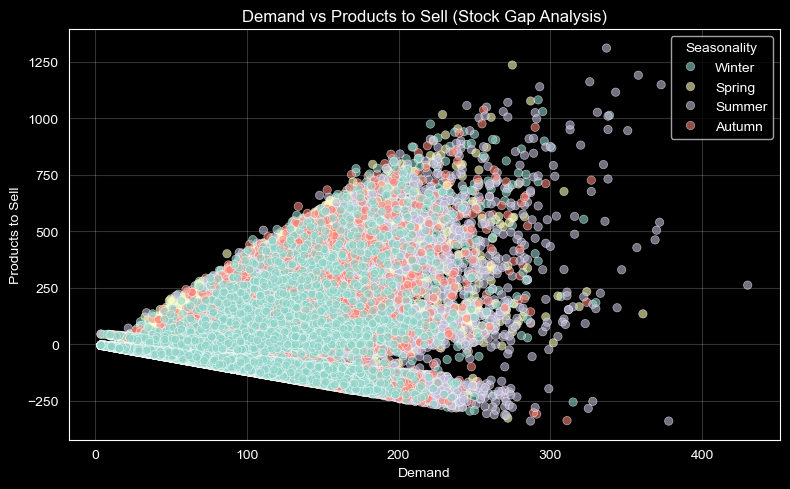

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Demand',
    y='Products_to_sell',
    hue='Seasonality',
    alpha=0.6
)

plt.title("Demand vs Products to Sell (Stock Gap Analysis)")
plt.xlabel("Demand")
plt.ylabel("Products to Sell")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

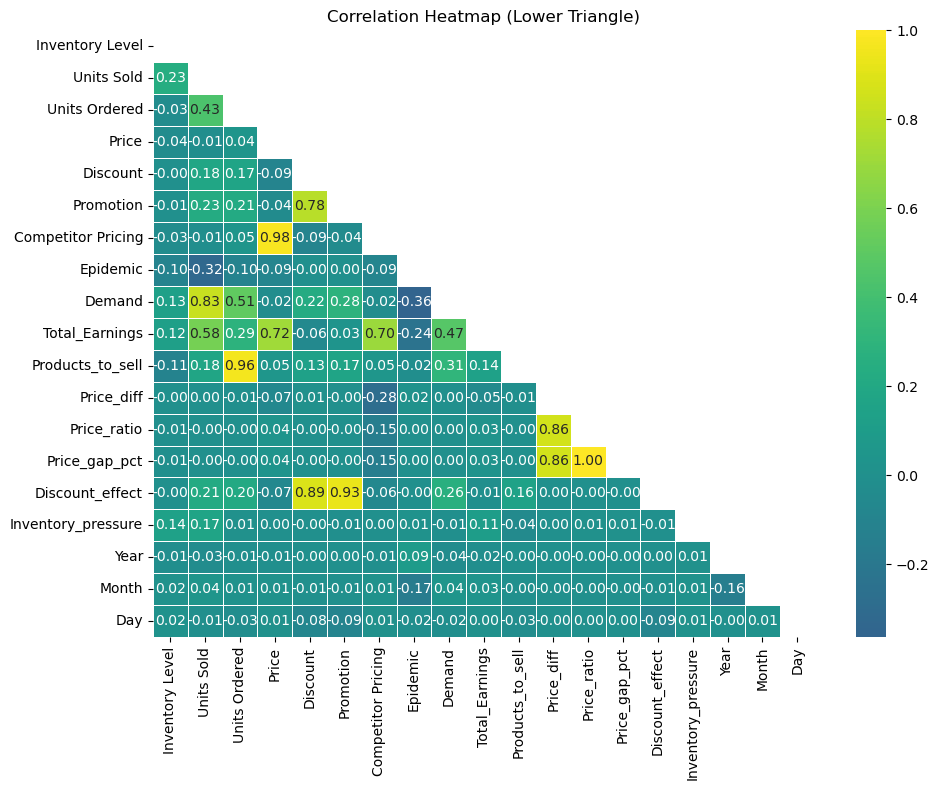

In [18]:
plt.style.use("default")

corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

In [19]:
df_model = df.copy()

df_model = df_model.drop(columns=[
    'Units Sold',
    'Units Ordered',
    'Products_to_sell',
    'Total_Earnings',
    'Price',
    'Date',
    'Store ID'
])

<div style="
background: linear-gradient(135deg, #020617 0%, #020617 100%);
border-radius: 14px;
padding: 18px 24px;
margin: 28px 0;
box-shadow: 0 12px 30px rgba(0,0,0,0.6);
font-family: Arial, Helvetica, sans-serif;
">

<h2 style="
margin: 0;
font-size: 26px;
font-weight: 700;
color: #e5e7eb;
letter-spacing: 0.6px;
">
🤖 Modeling & Prediction
</h2>

</div>

In [20]:
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

y = np.log1p(df_model['Demand'])
X = df_model.drop(columns=['Demand'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality','Product ID']

encoder = TargetEncoder(smoothing=0.3)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [21]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lgb_params = {
    'n_estimators': [500, 800, 1200, 1500],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 50, 70, 100],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
}

xgb_params = {
    'n_estimators': [500, 800, 1200, 1500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
}

lgb_search = RandomizedSearchCV(
    LGBMRegressor(
        random_state=42,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),
    lgb_params,
    n_iter=30,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),
    xgb_params,
    n_iter=30,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

lgb_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

lgb_best = lgb_search.best_estimator_
xgb_best = xgb_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


  File "C:\Users\Gaming\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Gaming\Anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Gaming\Anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Gaming\Anaconda3\Lib\subproc

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1636
[LightGBM] [Info] Number of data points in the train set: 60800, number of used features: 18
[LightGBM] [Info] Start training from score 4.538088
Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score
results = []

def evaluate_model(name, model):
    preds = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)
    
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "R2": r2
    })

evaluate_model("LightGBM", lgb_best)
evaluate_model("XGBoost", xgb_best)

results_df = pd.DataFrame(results)
print(results_df)

      Model       MAE        R2
0  LightGBM  7.965199  0.919297
1   XGBoost  8.495665  0.914340


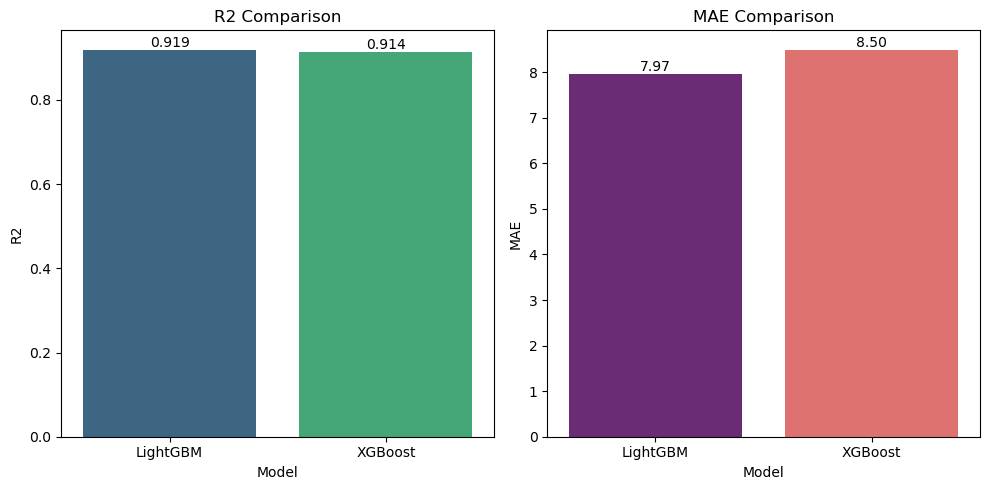

In [23]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(data=results_df, x="Model", y="R2", palette="viridis")
plt.title("R2 Comparison")

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f"{height:.3f}",
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom')

plt.subplot(1,2,2)
ax2 = sns.barplot(data=results_df, x="Model", y="MAE", palette="magma")
plt.title("MAE Comparison")

for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(f"{height:.2f}",
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [24]:
lgb_pred = np.expm1(lgb_best.predict(X_test))
xgb_pred = np.expm1(xgb_best.predict(X_test))

final_pred = 0.5 * lgb_pred + 0.5 * xgb_pred

print("ENSEMBLE")
print("MAE:", mean_absolute_error(np.expm1(y_test), final_pred))
print("R2:", r2_score(np.expm1(y_test), final_pred))

ENSEMBLE
MAE: 7.800422092622521
R2: 0.9225882609651288
